In [14]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [15]:
from typing import Annotated

from langchain_core.tools import tool
from langchain_community.tools import DuckDuckGoSearchResults
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_core.messages import BaseMessage
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def get_web_search(query: str, search_period: str='m') -> str:
    """
    웹 검색을 수행하는 함수.
    """
    wrapper = DuckDuckGoSearchAPIWrapper(
        time=search_period
    )

    print('\n-------- WEB SEARCH --------')
    print(query)
    print(search_period)

    search = DuckDuckGoSearchResults(
        api_wrapper=wrapper,
        results_separator=';\n'
    )

    searched = search.invoke(query)
    
    for i, result in enumerate(searched.split(';\n')):
        print(f'{i+1}. {result}')
    
    return searched

# 도구 바인딩
tools = [get_web_search]

llm_with_tools = llm.bind_tools(tools)

def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools=tools)
graph_builder.add_node("tools", tool_node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)
graph_builder.add_edge("tools", "chatbot")
graph_builder.add_edge(START, "chatbot")

memory = InMemorySaver()
graph = graph_builder.compile(checkpointer=memory)

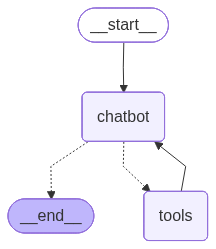

In [16]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [17]:
config = {"configurable": {"thread_id": "1"}}

events = graph.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": (
                    "LangGraph를 배우는 중입니다. "
                    "LangGraph에 대해 조사를 좀 해주시겠어요?"
                ),
            },
        ],
    },
    config,
    stream_mode="values",
)
for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================ Human Message =================================

LangGraph를 배우는 중입니다. LangGraph에 대해 조사를 좀 해주시겠어요?
================================== Ai Message ==================================
Tool Calls:
  get_web_search (2dcc7392-020c-4648-bedf-510598fdd82b)
 Call ID: 2dcc7392-020c-4648-bedf-510598fdd82b
  Args:
    query: LangGraph

-------- WEB SEARCH --------
LangGraph
m
1. snippet: Sep 2, 2025 · LangGraph is a low-level agent orchestration framework, giving developers durable execution and fine-grained control to run complex agentic systems in production., title: LangChain & LangGraph 1.0 alpha releases, link: https://blog.langchain.com/langchain-langchain-1-0-alpha-releases/
2. snippet: Sep 16, 2025 · Learn to build LangGraph Agents to automate code documentation. This guide uses AI to create a smart, self-documenting system., title: LangGraph Agents: A Guide to Building a Self-Documenting AI, link: https://www.analyticsvidhya.com/blog/2025/09/langgraph-agents

In [18]:
to_replay = None
for state in graph.get_state_history(config):
    print("Num Messages: ", len(state.values["messages"]), "Next: ", state.next)
    print("-" * 80)
    if len(state.values["messages"]) == 2:
        # We are somewhat arbitrarily selecting a specific state based on the number of chat messages in the state.
        to_replay = state

Num Messages:  4 Next:  ()
--------------------------------------------------------------------------------
Num Messages:  3 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  2 Next:  ('tools',)
--------------------------------------------------------------------------------
Num Messages:  1 Next:  ('chatbot',)
--------------------------------------------------------------------------------
Num Messages:  0 Next:  ('__start__',)
--------------------------------------------------------------------------------


In [19]:
print(to_replay.next)
print(to_replay.config)

('tools',)
{'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f09a9fb-3131-6980-8001-1f300c6024bb'}}


In [20]:
# The `checkpoint_id` in the `to_replay.config` corresponds to a state we've persisted to our checkpointer.
for event in graph.stream(None, to_replay.config, stream_mode="values"):
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  get_web_search (2dcc7392-020c-4648-bedf-510598fdd82b)
 Call ID: 2dcc7392-020c-4648-bedf-510598fdd82b
  Args:
    query: LangGraph

-------- WEB SEARCH --------
LangGraph
m
1. snippet: Sep 2, 2025 · LangGraph is a low-level agent orchestration framework, giving developers durable execution and fine-grained control to run complex agentic systems in production., title: LangChain & LangGraph 1.0 alpha releases, link: https://blog.langchain.com/langchain-langchain-1-0-alpha-releases/
2. snippet: Sep 16, 2025 · Learn to build LangGraph Agents to automate code documentation. This guide uses AI to create a smart, self-documenting system., title: LangGraph Agents: A Guide to Building a Self-Documenting AI, link: https://www.analyticsvidhya.com/blog/2025/09/langgraph-agents/
3. snippet: Sep 3, 2025 · LangGraph is a Python-based framework designed to manage multi-agent workflows using graph architecture